# NLP DONOSTI

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Librerías de Procesamiento de Lenguaje Natural (NLP)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
import re # Para expresiones regulares (limpiar símbolos)

# Recursos lingüísticos necesarios para el español
nltk.download('punkt')           # Tokenizador
nltk.download('stopwords') 
nltk.download('punkt_tab') # Palabras comunes sin valor semántico

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\adria\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adria\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\adria\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Cargamos y empezamos ha procesar el texto de las reseñas

In [2]:
text = os.path.join('Datos','transformados', "Donosti_booking_reviews_todas.csv")
df = pd.read_csv(text)

In [3]:
def clean_text_round(text):
    text = re.sub('\r', '', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('Â', '', text)
    text = re.sub('\u200a', '', text)
    return text

In [4]:
df['full_review'] = df['positive'].fillna('') + ' ' + df['negative'].fillna('')

In [5]:
df['full_review'] = df['full_review'].apply(clean_text_round)

In [6]:
lines = " ".join(df['full_review'])

In [7]:
sentences = sent_tokenize(lines)
total_documents = len(sentences)


In [8]:
documents_tokens = []

for sentence in sentences:
    tokens = word_tokenize(sentence, language='spanish')
    documents_tokens.append(tokens)


In [9]:
all_words = []

for doc in documents_tokens:
    all_words.extend(doc)

all_words = [w.lower() for w in all_words if w.isalpha()]



In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Stopwords en español
stop_words = stopwords.words('spanish')

vectorizer = CountVectorizer(
    stop_words=stop_words,
    lowercase=True
)

X = vectorizer.fit_transform(sentences)


In [11]:
X.shape


(53, 331)

In [12]:
tdm = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)


In [13]:
word_freq = tdm.sum(axis=0).sort_values(ascending=False)
print(word_freq.head(10))


habitación    14
bien          14
personal      11
precio        10
ubicación     10
buena          8
limpieza       6
lugar          5
camas          5
calidad        5
dtype: int64


### Creamos la matriz tf

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

stop_words = stopwords.words('spanish')

tf_vectorizer = TfidfVectorizer(
    use_idf=False,      # solo TF
    norm='l1',          # normaliza por documento
    stop_words=stop_words,  # quita stopwords
    lowercase=True
)

X_tf = tf_vectorizer.fit_transform(sentences)

# Convertir a DataFrame
tf_matrix = pd.DataFrame(
    X_tf.toarray(),
    columns=tf_vectorizer.get_feature_names_out()
)



         00        05   10        13        15        20  23h   48   4a  \
0  0.000000  0.000000  0.0  0.000000  0.000000  0.000000  0.0  0.0  0.0   
1  0.000000  0.000000  0.0  0.045455  0.090909  0.000000  0.0  0.0  0.0   
2  0.000000  0.000000  0.0  0.000000  0.000000  0.000000  0.0  0.0  0.0   
3  0.000000  0.000000  0.0  0.000000  0.000000  0.000000  0.0  0.0  0.0   
4  0.015873  0.015873  0.0  0.000000  0.000000  0.015873  0.0  0.0  0.0   

   abrió  ...  uso  vecinos     verde  viajeros  vista    vistas  vuelto  \
0    0.0  ...  0.0      0.0  0.000000       0.0    0.0  0.000000     0.0   
1    0.0  ...  0.0      0.0  0.000000       0.0    0.0  0.000000     0.0   
2    0.0  ...  0.0      0.0  0.000000       0.0    0.0  0.000000     0.0   
3    0.0  ...  0.0      0.0  0.000000       0.0    0.0  0.000000     0.0   
4    0.0  ...  0.0      0.0  0.015873       0.0    0.0  0.015873     0.0   

       zona     zonas  área  
0  0.000000  0.000000   0.0  
1  0.000000  0.000000   0.0  
2 

In [15]:
# Convertir a binario: 1 si aparece, 0 si no
binary_matrix = (tf_matrix > 0).astype(int)

# Sumar por columna → cuántas frases contienen cada palabra
word_in_sentences = binary_matrix.sum(axis=0)
word_in_sentences_sorted = word_in_sentences.sort_values(ascending=False)
print(word_in_sentences_sorted.head(10))


bien          13
habitación    11
precio        10
ubicación      9
buena          8
personal       7
limpieza       6
calidad        5
camas          5
lugar          5
dtype: int64


### Creamos el vector IDF

In [16]:
N = tf_matrix.shape[0]

idf_vector = np.log(N / word_in_sentences)
print(idf_vector.sort_values(ascending=False).head(10))


área     3.970292
00       3.970292
05       3.970292
10       3.970292
13       3.970292
15       3.970292
zonas    3.970292
23h      3.970292
48       3.970292
4a       3.970292
dtype: float64


### Creamos la matriz tf-idf

In [17]:
tfidf_matrix0 = tf_matrix * idf_vector


In [18]:
print(tfidf_matrix0.iloc[3].sort_values(ascending=False).head(10))


lejos     1.435840
centro    1.291999
10        0.000000
13        0.000000
15        0.000000
20        0.000000
23h       0.000000
48        0.000000
4a        0.000000
abrió     0.000000
Name: 3, dtype: float64


In [19]:
sentence_scores = tfidf_matrix0.apply(
    lambda row: row[row > 0].mean(),
    axis=1
)
print(sentence_scores.sort_values(ascending=False).head(10))


15    3.970292
35    1.582786
3     1.363919
18    1.343909
43    1.323431
26    1.246414
2     1.170622
29    1.152095
6     1.144604
46    0.992573
dtype: float64


In [20]:
average_score = sentence_scores.mean()
average_score

np.float64(0.6773213842085861)

In [21]:
def _generate_summary(sentences, sentence_scores, average_score):
    summary = ''
    sentence_count = 0
    
    for i, sentence in enumerate(sentences):
        if sentence_scores.iloc[i] >= average_score:
            summary += " " + sentence
            sentence_count += 1
            
    return summary


In [22]:
summary = _generate_summary(sentences, sentence_scores, 1.3 * average_score)
print(summary)

 En general todo bien. Un poco lejos del centro. Es un lugar ordenado y estructurado. Recomendable. El resto todo muy bien! Buena ubicación. Básicamente p gente joven. El personal muy amable . Y la habitación familiar amplia . Los vecinos un poco ruidosos pero a la noche se comportaron . Las camas no son cómodas. Camarotes sin cortina y muy pequeños. Las habitaciones son amplias y los colchones cómodos.


### Filtramos por opiniones negativas

In [23]:
# opiniones negativas
neg_reviews = df['negative'].dropna()

sentences = []
for review in neg_reviews:
    sentences.extend(sent_tokenize(review, language='spanish'))

print(f"Número de frases negativas: {len(sentences)}")


Número de frases negativas: 44


In [24]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Definir stopwords en español
stop_words_es = stopwords.words('spanish')

tfidf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- nombre correcto
    lowercase=True,
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(sentences)


In [25]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(tfidf_matrix)

labels = kmeans.labels_


c:\Users\adria\.conda\envs\R6_Amarillo\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [26]:
import numpy as np

# Número de palabras a mostrar por cluster
top_n = 15

# Nombres de las palabras del TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Orden de importancia de cada palabra en cada cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]  # de mayor a menor

# Mostrar las top 15 palabras por cluster
for i in range(k):  # k = número de clusters
    print(f"\nCluster {i} - Top {top_n} palabras clave:")
    top_words = [feature_names[ind] for ind in order_centroids[i, :top_n]]
    print(", ".join(top_words))




Cluster 0 - Top 15 palabras clave:
bien

Cluster 1 - Top 15 palabras clave:
bien

Cluster 2 - Top 15 palabras clave:
bien

Cluster 3 - Top 15 palabras clave:
bien


In [27]:
from nltk.corpus import stopwords
nltk.download('stopwords')  # si no lo has hecho ya

stop_words_es = stopwords.words('spanish')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adria\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- lista de NLTK
    lowercase=True
)

# Usar las mismas frases que para K-Means
neg_sentences = sentences  # o la lista exacta usada para labels

X_tf = tf_vectorizer.fit_transform(neg_sentences)
tfidf_matrix0 = pd.DataFrame(X_tf.toarray(), columns=tf_vectorizer.get_feature_names_out())



### Sacamos 4 clusters para analizar los puntos de mejora.

#### En los cluster encontramos titulos, palabras y ejemplos de frase

In [29]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

top_n_words = 15
top_n_sentences = 5
k = len(np.unique(labels))

# Diccionario para nombrar clusters según interpretación de palabras
# Puedes ajustar los nombres según lo que observes
cluster_names = {
    0: "Comodidad y equipamiento",
    1: "Ubicación y accesibilidad",
    2: "Limpieza y confort",
    3: "Comodidad + ubicación"
}

for i in range(k):
    # Frases del cluster
    cluster_sentences = [sent for sent, label in zip(sentences, labels) if label == i]
    
    # TF-IDF promedio por palabra dentro del cluster
    cluster_rows = tfidf_matrix0.iloc[[j for j, l in enumerate(labels) if l == i]]
    tfidf_mean = cluster_rows.mean(axis=0)
    
    # Top palabras
    top_words = tfidf_mean.sort_values(ascending=False).head(top_n_words).index.tolist()
    
    print(f"\nCluster {i} - {cluster_names.get(i, 'Tema desconocido')}")
    print(f"Top {top_n_words} palabras: {', '.join(top_words)}")
    
    # Ejemplos de frases
    print(f"Ejemplos de frases ({top_n_sentences}):")
    for sent in cluster_sentences[:top_n_sentences]:
        print("-", sent)



Cluster 0 - Comodidad y equipamiento
Top 15 palabras: lejos, habitación, camas, centro, dormir, cafetería, desayuno, mensaje, quizás, baño, noche, ducha, cortinas, parking, horas
Ejemplos de frases (5):
- Las toallas no secan y el jabón de la ducha complicado para salir
- Poca presión en la ducha
- Que no te dejen entrar hasta las 15 horas y que si te dejan antes, a las 13 horas, hay que pagar 15 euros.
- Un poco lejos del centro.
- No es fácil encontrar aparcamiento si llevas coche y es zona verde (de pago, aunque la mañana de un sábado son solo 4 € mucho más económico que un parking)

Cluster 1 - Ubicación y accesibilidad
Top 15 palabras: bien, resto, mucha, precio, gente, bastante, abrió, acaparar, acceso, aire, 13, 15, 00, 05, alojamiento
Ejemplos de frases (5):
- El resto todo muy bien!
- Todo fue bien
- Había mucha gente, pero por el precio, está bastante bien
- Todo muy bien
- Todo bien


## Tabla de frecuencias y wordcloud y graficos

In [30]:
negative_reviews = df['negative'].dropna()
negative_reviews = negative_reviews.apply(clean_text_round)

# Unir todo el texto negativo
negative_text = " ".join(negative_reviews)

In [31]:
# Tokenizar palabras
tokens_neg = word_tokenize(negative_text, language='spanish')

# Limpiar: minúsculas, alfabéticas, sin stopwords
stop_words_es = stopwords.words('spanish')

tokens_neg_clean = [
    w.lower() for w in tokens_neg
    if w.isalpha() and w.lower() not in stop_words_es
]

In [32]:
# Tabla de frecuencias
freq_neg = pd.Series(tokens_neg_clean).value_counts()

# Convertir a DataFrame
freq_neg_df = freq_neg.reset_index()
freq_neg_df.columns = ['Palabra', 'Frecuencia']

print("\nTop 20 palabras negativas más frecuentes:")
print(freq_neg_df.head(20))


Top 20 palabras negativas más frecuentes:
       Palabra  Frecuencia
0         bien           5
1   habitación           4
2        noche           3
3        camas           3
4        lejos           3
5        horas           3
6    alrededor           2
7       quizás           2
8        cerca           2
9       dormir           2
10     parking           2
11      centro           2
12       salir           2
13    personal           2
14     pequeña           2
15    cortinas           2
16        hace           2
17        baño           2
18          si           2
19       ducha           2


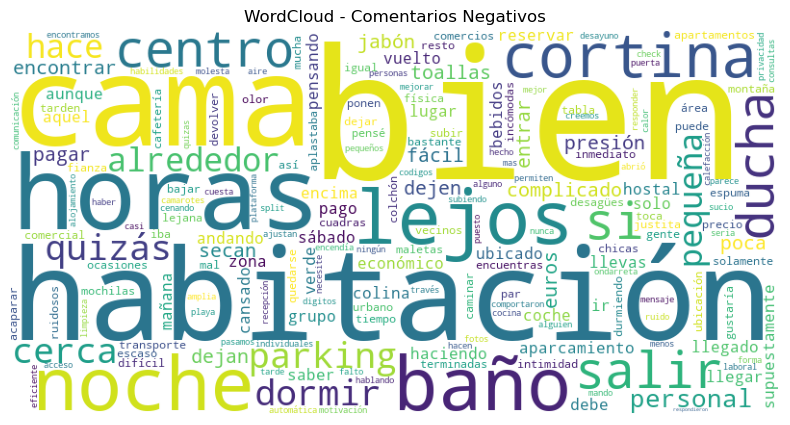

In [33]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(" ".join(tokens_neg_clean))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud - Comentarios Negativos")
plt.show()

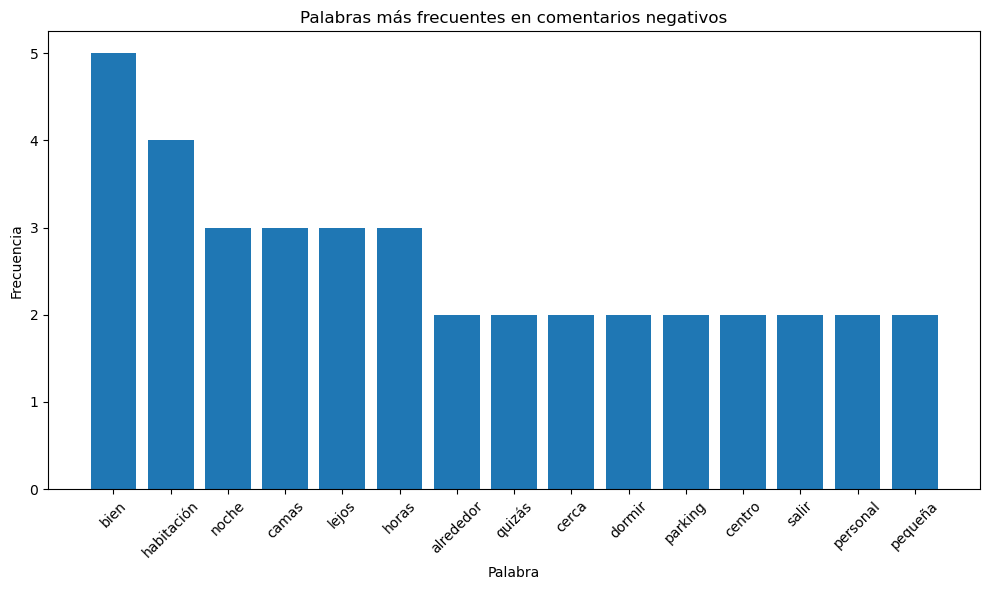

In [34]:
top_n = 15
top_words = freq_neg_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.bar(top_words['Palabra'], top_words['Frecuencia'])
plt.xticks(rotation=45)
plt.title("Palabras más frecuentes en comentarios negativos")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()